In [3]:
# Análise de Renda para Meses Selecionados

# Este notebook carrega, filtra e gera gráficos para a base de dados de previsão de renda, focando nos meses de março, abril, maio, junho e dezembro.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [7]:
# Carregar a base de dados
df = pd.read_csv('previsao_de_renda.csv')

# Conversão da coluna de data para o tipo datetime
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Filtrar o DataFrame para incluir apenas os meses de interesse
meses_de_interesse = [3, 4, 5, 6, 12] # março, abril, maio, junho, dezembro
df_filtrado = df[df['data_ref'].dt.month.isin(meses_de_interesse)].copy()

# Limpeza e preparação adicional dos dados
# Remover linhas com valores ausentes
df_filtrado.dropna(inplace=True)

# Garantir que a renda seja positiva para análise
df_filtrado = df_filtrado[df_filtrado['renda'] > 0]

print(f"Dados carregados e filtrados. Total de linhas para análise: {len(df_filtrado)}")

Dados carregados e filtrados. Total de linhas para análise: 4928


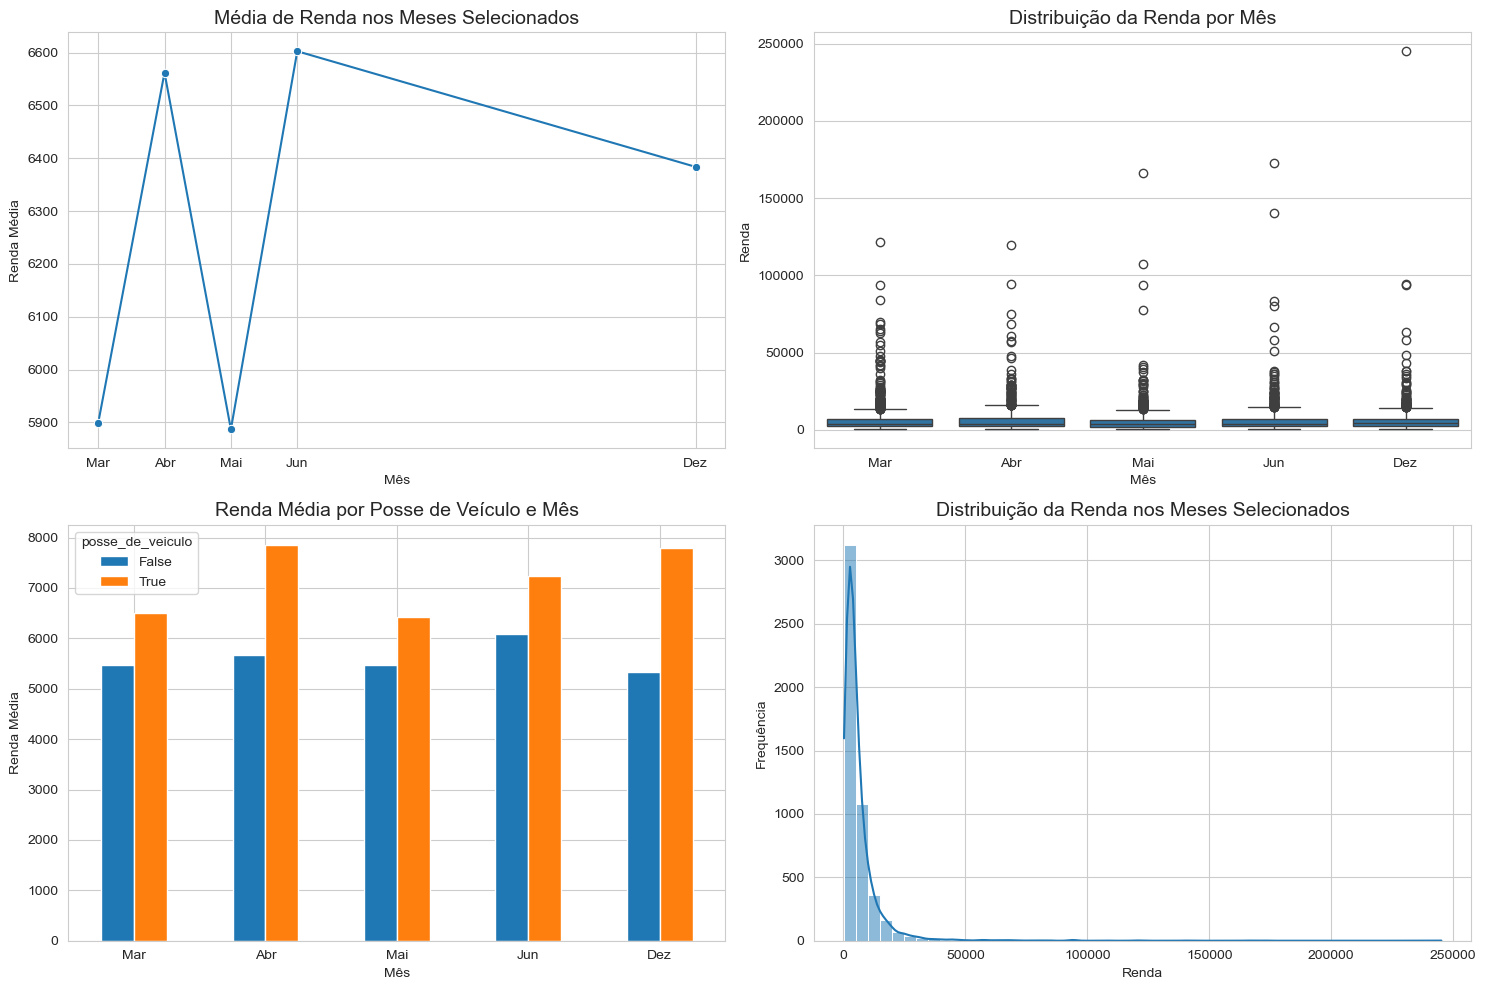

In [11]:
# Configurar o estilo dos gráficos
sns.set_style('whitegrid')
plt.figure(figsize=(15, 10))

# Mapeamento para nomes de meses
month_map = {3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 12: 'Dez'}

# --- Gráfico 1: Renda Média por Mês (Linha) ---
plt.subplot(2, 2, 1)
media_renda_por_mes = df_filtrado.groupby(df_filtrado['data_ref'].dt.month)['renda'].mean()
sns.lineplot(x=media_renda_por_mes.index, y=media_renda_por_mes.values, marker='o')
plt.title('Média de Renda nos Meses Selecionados', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Renda Média')
plt.xticks(ticks=media_renda_por_mes.index, labels=media_renda_por_mes.index.map(month_map))


# --- Gráfico 2: Distribuição da Renda (Boxplot) ---
plt.subplot(2, 2, 2)
sns.boxplot(x=df_filtrado['data_ref'].dt.month.map(month_map), y='renda', data=df_filtrado)
plt.title('Distribuição da Renda por Mês', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Renda')


# --- Gráfico 3: Renda Média por Posse de Veículo e Mês (Barras) ---
plt.subplot(2, 2, 3)
# Agrupar por mês, não pela data_ref completa, e renomear o índice
media_renda_posse = df_filtrado.groupby([df_filtrado['data_ref'].dt.month, 'posse_de_veiculo'])['renda'].mean().unstack()
media_renda_posse.rename(index=month_map, inplace=True)
media_renda_posse.plot(kind='bar', ax=plt.gca())
plt.title('Renda Média por Posse de Veículo e Mês', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Renda Média')
plt.xticks(rotation=0)


# --- Gráfico 4: Distribuição da Renda (Histograma) ---
plt.subplot(2, 2, 4)
sns.histplot(df_filtrado['renda'], kde=True, bins=50)
plt.title('Distribuição da Renda nos Meses Selecionados', fontsize=14)
plt.xlabel('Renda')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

In [ ]:
# Como Automatizar a Geração de Gráficos

# Para tornar o processo de geração de gráficos mais eficiente e reutilizável para meses ou anos futuros, a melhor abordagem é automatizar o fluxo de trabalho com funções.

# Em vez de copiar e colar o código e alterar as listas de meses manualmente, podemos criar uma função que realiza todas as etapas (filtra, processa e plota) com base nos parâmetros que você fornecer.

Gerando gráficos para os meses: ['Mar', 'Abr', 'Mai', 'Jun', 'Dez']


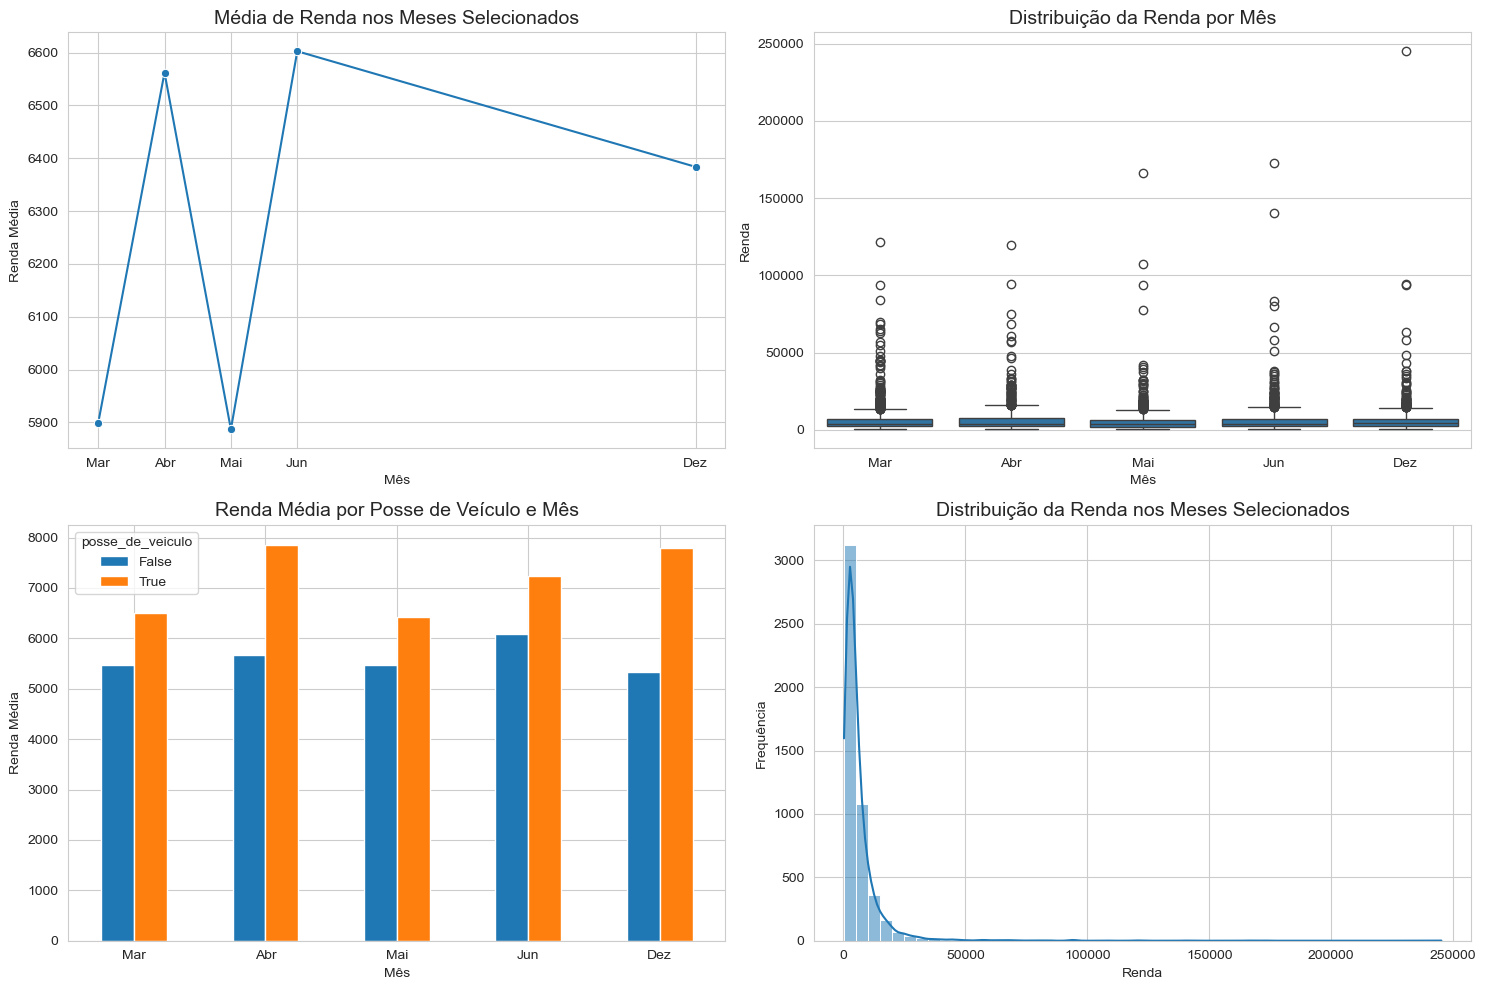

In [15]:
# Mapeamento para nomes de meses, útil para rótulos
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
             7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

def gerar_graficos_renda_por_mes(df: pd.DataFrame, meses: list):
    """
    Filtra a base de dados por uma lista de meses e gera gráficos de análise de renda.

    Args:
        df (pd.DataFrame): DataFrame original com a coluna 'data_ref' já em formato datetime.
        meses (list): Lista de números inteiros representando os meses (ex: [3, 4, 5]).
    """
    # 1. Filtrar os dados para os meses de interesse
    df_filtrado = df[df['data_ref'].dt.month.isin(meses)].copy()
    
    # Adicionalmente, garantir que os dados estejam limpos para a análise
    df_filtrado.dropna(inplace=True)
    df_filtrado = df_filtrado[df_filtrado['renda'] > 0]
    
    print(f"Gerando gráficos para os meses: {[month_map[m] for m in meses]}")

    # 2. Gerar os gráficos (código da célula anterior)
    sns.set_style('whitegrid')
    plt.figure(figsize=(15, 10))

    # Gráfico 1: Média de Renda por Mês (Linha)
    plt.subplot(2, 2, 1)
    media_renda_por_mes = df_filtrado.groupby(df_filtrado['data_ref'].dt.month)['renda'].mean()
    sns.lineplot(x=media_renda_por_mes.index, y=media_renda_por_mes.values, marker='o')
    plt.title('Média de Renda nos Meses Selecionados', fontsize=14)
    plt.xlabel('Mês')
    plt.ylabel('Renda Média')
    plt.xticks(ticks=media_renda_por_mes.index, labels=media_renda_por_mes.index.map(month_map))

    # Gráfico 2: Distribuição da Renda (Boxplot)
    plt.subplot(2, 2, 2)
    sns.boxplot(x=df_filtrado['data_ref'].dt.month.map(month_map), y='renda', data=df_filtrado)
    plt.title('Distribuição da Renda por Mês', fontsize=14)
    plt.xlabel('Mês')
    plt.ylabel('Renda')

    # Gráfico 3: Renda Média por Posse de Veículo e Mês (Barras)
    plt.subplot(2, 2, 3)
    media_renda_posse = df_filtrado.groupby([df_filtrado['data_ref'].dt.month, 'posse_de_veiculo'])['renda'].mean().unstack()
    media_renda_posse.rename(index=month_map, inplace=True)
    media_renda_posse.plot(kind='bar', ax=plt.gca())
    plt.title('Renda Média por Posse de Veículo e Mês', fontsize=14)
    plt.xlabel('Mês')
    plt.ylabel('Renda Média')
    plt.xticks(rotation=0)

    # Gráfico 4: Distribuição da Renda (Histograma)
    plt.subplot(2, 2, 4)
    sns.histplot(df_filtrado['renda'], kde=True, bins=50)
    plt.title('Distribuição da Renda nos Meses Selecionados', fontsize=14)
    plt.xlabel('Renda')
    plt.ylabel('Frequência')

    plt.tight_layout()
    plt.show()

# Exemplo de uso da função para os meses anteriores
df_original = pd.read_csv('previsao_de_renda.csv')
df_original['data_ref'] = pd.to_datetime(df_original['data_ref'])
gerar_graficos_renda_por_mes(df_original, [3, 4, 5, 6, 12])

# Exemplo de como usar para novos meses
# gerar_graficos_renda_por_mes(df_original, [1, 2, 7, 8])